# Evaluasi Model N-Gram

Notebook ini mengevaluasi model N-Gram aktual dari project, bukan korpus contoh. Data evaluasi berasal dari `model/specil_test.csv`, sedangkan artifact model berasal dari `model/n_gram/ngram_spell_checker.json.gz`.


In [9]:
from pathlib import Path
import csv
import math
import statistics
import sys
import time

ROOT = Path.cwd()
if not (ROOT / 'app.py').exists():
    ROOT = ROOT.parent.parent

sys.path.insert(0, str(ROOT / 'model' / 'n_gram'))
from ngram_spell_checker import NGramSpellChecker, generate_ngrams, tokenize_words

TEST_PATH = ROOT / 'model' / 'specil_test.csv'
MODEL_PATH = ROOT / 'model' / 'n_gram' / 'ngram_spell_checker.json.gz'
LIMIT = 200
print(ROOT)


e:\8. Mata Kuliah\Semester 6\IoT Kecerdasan Artifisial\FinalProject_MorseNLP


In [10]:
def load_pairs(limit=LIMIT):
    rows = []
    with TEST_PATH.open(encoding='utf-8', newline='') as f:
        for row in csv.DictReader(f):
            rows.append((row['wrong_text'], row['correct_text'], row.get('error_type', '')))
            if len(rows) >= limit:
                break
    return rows

pairs = load_pairs()
ngram = NGramSpellChecker.load(MODEL_PATH)
len(pairs), pairs[:2]


(200,
 [('diskusikan gambar sampul di atas dengan menawab pertanyaan-pertanyaan ini .',
   'diskusikan gambar sampul di atas dengan menjawab pertanyaan-pertanyaan ini .',
   'Deletion Error'),
  ('bola boni bir .', 'bola boni biru .', 'Deletion Error')])

In [11]:
def levenshtein(a, b):
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        cur = [i]
        for j, cb in enumerate(b, 1):
            cur.append(min(prev[j] + 1, cur[-1] + 1, prev[j - 1] + (ca != cb)))
        prev = cur
    return prev[-1]

def wer(reference, hypothesis):
    ref, hyp = reference.split(), hypothesis.split()
    return levenshtein(ref, hyp) / max(len(ref), 1)

def cer(reference, hypothesis):
    return levenshtein(list(reference.replace(' ', '')), list(hypothesis.replace(' ', ''))) / max(len(reference.replace(' ', '')), 1)

def prf(wrong, target, pred):
    wrong_tokens = tokenize_words(wrong)
    target_tokens = tokenize_words(target)
    pred_tokens = tokenize_words(pred)
    width = max(len(wrong_tokens), len(target_tokens), len(pred_tokens))
    tp = fp = fn = tn = 0
    for i in range(width):
        w = wrong_tokens[i] if i < len(wrong_tokens) else ''
        t = target_tokens[i] if i < len(target_tokens) else ''
        p = pred_tokens[i] if i < len(pred_tokens) else ''
        actual_typo = w != t
        changed = w != p
        correct_change = changed and p == t
        if actual_typo and correct_change:
            tp += 1
        elif not actual_typo and changed:
            fp += 1
        elif actual_typo and not correct_change:
            fn += 1
        else:
            tn += 1
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return precision, recall, f1, tp, fp, fn, tn


In [12]:
def char_trigram_perplexity(model, texts):
    table = model.ngram_frequency['3']
    total = sum(table.values())
    vocab_size = max(len(table), 1)
    nll = 0.0
    count = 0
    for text in texts:
        for word in tokenize_words(text):
            for gram in generate_ngrams(word, [3], model.config['use_boundary_markers'])['3']:
                probability = (table.get(gram, 0) + 1) / (total + vocab_size)
                nll -= math.log(probability)
                count += 1
    return math.exp(nll / max(count, 1))

ngram_perplexity = char_trigram_perplexity(ngram, [target for _, target, _ in pairs])
ngram_perplexity


948.3553701590877

In [13]:
rows = []
for wrong, target, error_type in pairs:
    start = time.perf_counter()
    pred = ngram.correct(wrong)
    latency_ms = (time.perf_counter() - start) * 1000
    precision, recall, f1, tp, fp, fn, tn = prf(wrong, target, pred)
    rows.append({
        'wrong': wrong,
        'target': target,
        'prediction': pred,
        'error_type': error_type,
        'wer': wer(target, pred),
        'cer': cer(target, pred),
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'latency_ms': latency_ms,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn,
    })

summary = {
    'model': 'N-Gram',
    'rows': len(rows),
    'perplexity_char_trigram': ngram_perplexity,
    'wer_avg': statistics.mean(r['wer'] for r in rows),
    'cer_avg': statistics.mean(r['cer'] for r in rows),
    'precision_avg': statistics.mean(r['precision'] for r in rows),
    'recall_avg': statistics.mean(r['recall'] for r in rows),
    'f1_avg': statistics.mean(r['f1'] for r in rows),
    'latency_ms_avg': statistics.mean(r['latency_ms'] for r in rows),
}
summary


{'model': 'N-Gram',
 'rows': 200,
 'perplexity_char_trigram': 948.3553701590877,
 'wer_avg': 0.05850339244089244,
 'cer_avg': 0.01968075805782272,
 'precision_avg': 0.6,
 'recall_avg': 0.6,
 'f1_avg': 0.6,
 'latency_ms_avg': 57.926574499961134}

In [14]:
# Contoh hasil terburuk berdasarkan WER.
sorted(rows, key=lambda r: r['wer'], reverse=True)[:10]


[{'wrong': 'selmat bermain !',
  'target': 'selamat bermain !',
  'prediction': 'selat bermain !',
  'error_type': 'Deletion Error',
  'wer': 0.3333333333333333,
  'cer': 0.13333333333333333,
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0,
  'latency_ms': 184.50399999710498,
  'tp': 0,
  'fp': 0,
  'fn': 1,
  'tn': 1},
 {'wrong': 'bola boni bir .',
  'target': 'bola boni biru .',
  'prediction': 'bola boni air .',
  'error_type': 'Deletion Error',
  'wer': 0.25,
  'cer': 0.15384615384615385,
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0,
  'latency_ms': 41.36609999841312,
  'tp': 0,
  'fp': 0,
  'fn': 1,
  'tn': 2},
 {'wrong': 'pada siang har ?',
  'target': 'pada siang hari ?',
  'prediction': 'pada siang har ?',
  'error_type': 'Deletion Error',
  'wer': 0.25,
  'cer': 0.07142857142857142,
  'precision': 0.0,
  'recall': 0.0,
  'f1': 0.0,
  'latency_ms': 0.032400002965005115,
  'tp': 0,
  'fp': 0,
  'fn': 1,
  'tn': 2},
 {'wrong': 'pada malam har ?',
  'target': 'pada malam hari

<>:4: SyntaxWarning: invalid escape sequence '\p'
<>:4: SyntaxWarning: invalid escape sequence '\p'
C:\Users\-\AppData\Local\Temp\ipykernel_25516\402391882.py:4: SyntaxWarning: invalid escape sequence '\p'
  print('Matplotlib belum terpasang. Jalankan: .env\python.exe -m pip install matplotlib')


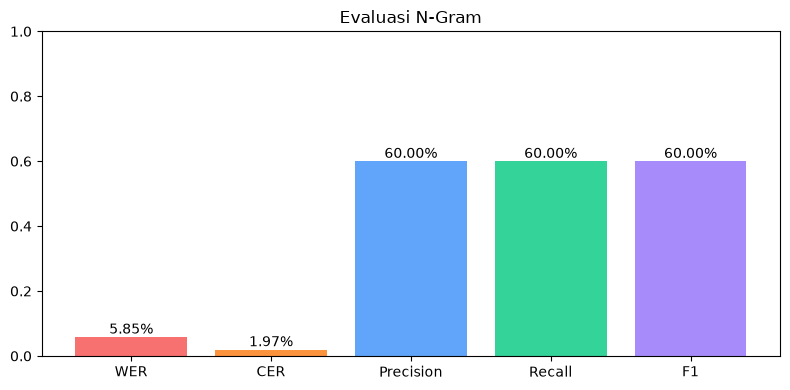

In [15]:
try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    print('Matplotlib belum terpasang. Jalankan: .env\python.exe -m pip install matplotlib')
else:
    labels = ['WER', 'CER', 'Precision', 'Recall', 'F1']
    values = [summary['wer_avg'], summary['cer_avg'], summary['precision_avg'], summary['recall_avg'], summary['f1_avg']]
    plt.figure(figsize=(8, 4))
    plt.bar(labels, values, color=['#f87171', '#fb923c', '#60a5fa', '#34d399', '#a78bfa'])
    plt.ylim(0, 1)
    plt.title('Evaluasi N-Gram')
    for i, value in enumerate(values):
        plt.text(i, value, f'{value:.2%}', ha='center', va='bottom')
    plt.tight_layout()
    plt.show()
